# Introduccion al Procesamiento de Lenguaje Natural (NLP)

**Duracion estimada:** ~2 horas  
**Nivel:** Introductorio  
**Requisitos previos:** Python basico, nociones de programacion

**Dataset:** [Amazon Reviews Multi ES](https://huggingface.co/datasets/SetFit/amazon_reviews_multi_es) - 200K resenas reales de Amazon en espanol con ratings de 1 a 5 estrellas

---

## Agenda

| Bloque | Tema | Duracion |
|--------|------|----------|
| 1 | Que es NLP y por que importa | 15 min |
| 2 | Exploracion del dataset | 15 min |
| 3 | Preprocesamiento de texto | 25 min |
| 4 | Representacion de texto: Bag of Words y TF-IDF | 20 min |
| 5 | Clasificacion de sentimiento con Machine Learning | 25 min |
| 6 | Introduccion a Word Embeddings | 15 min |
| 7 | Cierre y recursos adicionales | 5 min |

---
## 0. Instalacion de dependencias

In [1]:
!uv pip install nltk scikit-learn matplotlib numpy pandas gensim datasets

Using Python 3.11.13 environment at: /home/robert/Documents/Trabajo/Semillero investigación/introduccion_al_nlp/.venv
Audited 7 packages in 3ms


In [2]:
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to /home/robert/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /home/robert/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /home/robert/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /home/robert/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [3]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

print("Librerias cargadas correctamente.")

Librerias cargadas correctamente.


---
## 1. Que es NLP y por que importa (~15 min)

### Definicion

El **Procesamiento de Lenguaje Natural (NLP)** es un campo de la inteligencia artificial que se enfoca en la interaccion entre computadoras y el lenguaje humano. Su objetivo es que las maquinas puedan **entender, interpretar y generar** texto de manera util.

### Aplicaciones en el mundo real

- **Chatbots y asistentes virtuales** (Siri, Alexa, ChatGPT)
- **Traduccion automatica** (Google Translate, DeepL)
- **Analisis de sentimiento** (opiniones en redes sociales, resenas) <-- Lo que haremos hoy!
- **Resumen automatico** de textos
- **Extraccion de informacion** de documentos
- **Clasificacion de correos** (spam vs. no spam)
- **Busqueda semantica** (Google, motores de busqueda)

### Por que es dificil?

El lenguaje humano es:
- **Ambiguo**: "El banco esta cerca" (banco financiero o banco del parque?)
- **Contextual**: "Hace frio" puede ser una queja o una invitacion a cerrar la ventana
- **Variable**: jerga, regionalismos, errores ortograficos
- **Implicito**: mucho del significado no esta en las palabras explicitas

### Pipeline tipico de NLP

```
Texto crudo -> Preprocesamiento -> Representacion numerica -> Modelo -> Resultado
```

### Ejercicio de discusion

Piensen en 2-3 aplicaciones de NLP que usen en su dia a dia. Compartan con el grupo.

---
## 2. Exploracion del dataset (~15 min)

Vamos a trabajar con **resenas reales de Amazon en espanol**. El dataset contiene 200,000 resenas de productos con ratings de 1 a 5 estrellas (labels 0-4).

### 2.1 Cargar el dataset

In [4]:
from datasets import load_dataset

# Cargar resenas de Amazon en espanol
dataset = load_dataset("SetFit/amazon_reviews_multi_es")
print(dataset)

/home/robert/Documents/Trabajo/Semillero investigación/introduccion_al_nlp/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Repo card metadata block was not found. Setting CardData to empty.


DatasetDict({
    train: Dataset({
        features: ['id', 'text', 'label', 'label_text'],
        num_rows: 200000
    })
    validation: Dataset({
        features: ['id', 'text', 'label', 'label_text'],
        num_rows: 5000
    })
    test: Dataset({
        features: ['id', 'text', 'label', 'label_text'],
        num_rows: 5000
    })
})


In [5]:
# Convertir a DataFrame y tomar una muestra manejable
df_full = dataset["train"].to_pandas()
df = df_full.sample(n=5000, random_state=42).reset_index(drop=True)

# El label va de 0 a 4, lo convertimos a estrellas 1-5 para que sea mas intuitivo
df["estrellas"] = df["label"] + 1

print(f"Muestra de trabajo: {len(df)} resenas")
print(f"Columnas: {list(df.columns)}")
df.head()

Muestra de trabajo: 5000 resenas
Columnas: ['id', 'text', 'label', 'label_text', 'estrellas']


,id,text,label,label_text,estrellas
0,es_0407390,Mini usb cable de carga defectuoso por lo cual...,2,2,3
1,es_0543653,El cable es muy largo y es comodo pero me duró...,1,1,2
2,es_0723575,Ideal para mis necesidades.,3,3,4
3,es_0051657,"Es desigual el color, y mancha. El hilo de rom...",1,1,2
4,es_0500242,Los comentarios se hacen cuando uno recibe la ...,0,0,1


### 2.2 Explorar la estructura

In [6]:
print("=== Informacion general ===")
print(f"Filas: {len(df)}")
print(f"\n=== Valores nulos ===")
print(df.isnull().sum())
print(f"\n=== Longitud promedio de resenas (caracteres) ===")
print(df["text"].str.len().describe().round(1))

=== Informacion general ===
Filas: 5000

=== Valores nulos ===
id            0
text          0
label         0
label_text    0
estrellas     0
dtype: int64

=== Longitud promedio de resenas (caracteres) ===
count    5000.0
mean      151.1
std       128.3
min        20.0
25%        67.0
50%       120.0
75%       186.0
max      1535.0
Name: text, dtype: float64


=== Distribucion de estrellas ===
estrellas
1    1007
2     982
3    1003
4     987
5    1021
Name: count, dtype: int64


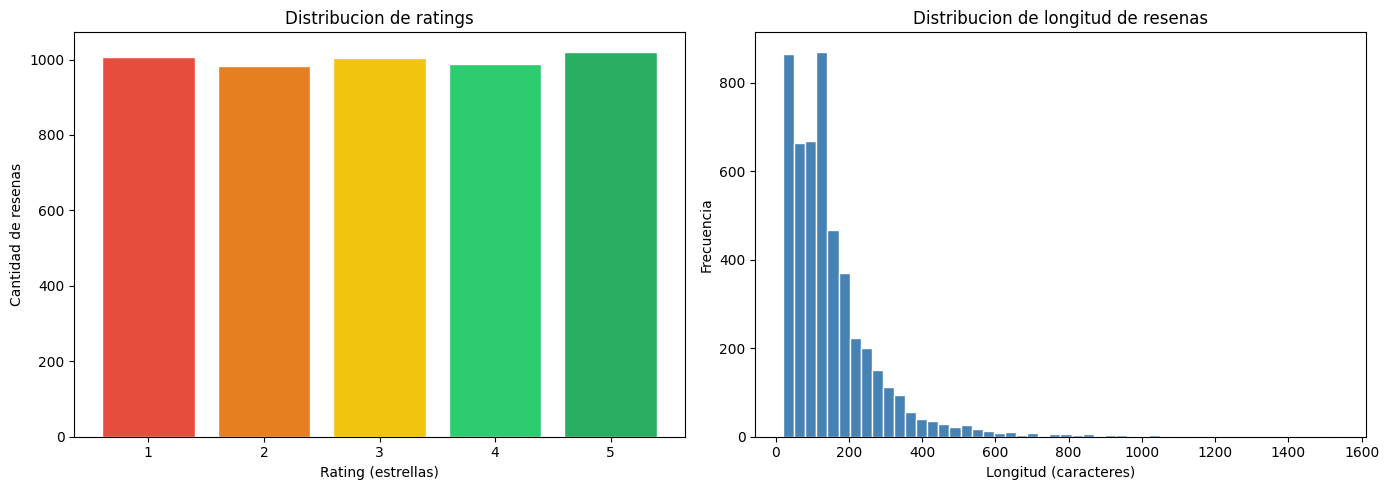

In [7]:
# Distribucion de ratings
print("=== Distribucion de estrellas ===")
print(df["estrellas"].value_counts().sort_index())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma de ratings
colores_rating = ['#e74c3c', '#e67e22', '#f1c40f', '#2ecc71', '#27ae60']
conteos = df["estrellas"].value_counts().sort_index()
axes[0].bar(conteos.index, conteos.values, color=colores_rating, edgecolor='white')
axes[0].set_xlabel('Rating (estrellas)')
axes[0].set_ylabel('Cantidad de resenas')
axes[0].set_title('Distribucion de ratings')
axes[0].set_xticks([1, 2, 3, 4, 5])

# Distribucion de longitud de resenas
axes[1].hist(df["text"].str.len(), bins=50, color='steelblue', edgecolor='white')
axes[1].set_xlabel('Longitud (caracteres)')
axes[1].set_ylabel('Frecuencia')
axes[1].set_title('Distribucion de longitud de resenas')

plt.tight_layout()
plt.show()

In [8]:
# Ver algunas resenas de ejemplo
print("=== Ejemplos de resenas por rating ===")
for rating in [1, 3, 5]:
    print(f"\n--- {rating} estrella(s) ---")
    ejemplos_rating = df[df["estrellas"] == rating]["text"].head(3)
    for texto in ejemplos_rating:
        print(f"  {str(texto)[:120]}...")

=== Ejemplos de resenas por rating ===

--- 1 estrella(s) ---
  Los comentarios se hacen cuando uno recibe la mercancía. antes de recibirla es imposible si llega el lunes serán 5 días ...
  Después de estar esperando a que me envíen el producto 1 mes, me indican que no tienen stock y me devuelven el dinero. Y...
  El producto nunca me llegó, no lo he podido probar. Cuando hice el pedido había stock pero una vez pagado me dijeron que...

--- 3 estrella(s) ---
  Mini usb cable de carga defectuoso por lo cual se estropearon los usb de las baterias...
  Es lo que esperaba de una funda para el móvil...
  Funciona bastante bien pero es poco el producto en si.Me lo acabé en una pasada.Podrian haber puesto un recipiente mas g...

--- 5 estrella(s) ---
  se adapta a mis necesidades...
  Me gusta la fuerza que tiene,tanto para picar como para hacer taladros.No sirve para taladros delicados porque oscila un...
  Es un champú, que para ser sin sulfatos, hace una espuma suave y no deja el pelo estr

### 2.3 Simplificar a sentimiento binario

Para esta sesion introductoria, vamos a simplificar los 5 ratings a **sentimiento binario**:
- Ratings 1-2 estrellas -> **negativo**
- Ratings 4-5 estrellas -> **positivo**
- Rating 3 -> lo descartamos (ambiguo)

In [9]:
# Crear etiquetas de sentimiento
df_sentimiento = df[df["estrellas"] != 3].copy()
df_sentimiento["sentimiento"] = df_sentimiento["estrellas"].apply(
    lambda x: "positivo" if x >= 4 else "negativo"
)

# Eliminar resenas vacias
df_sentimiento = df_sentimiento.dropna(subset=["text"])
df_sentimiento = df_sentimiento[df_sentimiento["text"].str.strip() != ""].reset_index(drop=True)

print(f"Resenas con sentimiento: {len(df_sentimiento)}")
print(f"\nDistribucion:")
print(df_sentimiento["sentimiento"].value_counts())

Resenas con sentimiento: 3997

Distribucion:
sentimiento
positivo    2008
negativo    1989
Name: count, dtype: int64


---
## 3. Preprocesamiento de texto (~25 min)

Antes de que un modelo pueda trabajar con texto, necesitamos **limpiarlo y normalizarlo**. Este es uno de los pasos mas importantes en cualquier proyecto de NLP.

### 3.1 Limpieza basica

Pasos comunes:
1. Convertir a minusculas
2. Eliminar caracteres especiales y numeros
3. Eliminar espacios extra

In [10]:
def limpiar_texto(texto):
    """Limpieza basica de texto."""
    texto = str(texto)
    # Convertir a minusculas
    texto = texto.lower()
    # Eliminar caracteres especiales (mantener letras, espacios y caracteres espanoles)
    texto = re.sub(r'[^a-z\u00e1\u00e9\u00ed\u00f3\u00fa\u00fc\u00f1\s]', '', texto)
    # Eliminar espacios multiples
    texto = re.sub(r'\s+', ' ', texto).strip()
    return texto

# Aplicar a unas resenas de ejemplo
ejemplos = df_sentimiento["text"].head(5).tolist()

print("=== Antes y despues de limpiar ===")
for original in ejemplos:
    limpio = limpiar_texto(original)
    print(f"ORIGINAL: {str(original)[:100]}")
    print(f"LIMPIO:   {limpio[:100]}")
    print()

=== Antes y despues de limpiar ===
ORIGINAL: El cable es muy largo y es comodo pero me duró poco tiempo porque el conector microusb se me acabó d
LIMPIO:   el cable es muy largo y es comodo pero me duró poco tiempo porque el conector microusb se me acabó d

ORIGINAL: Ideal para mis necesidades.
LIMPIO:   ideal para mis necesidades

ORIGINAL: Es desigual el color, y mancha. El hilo de rompe con demasiada facilidad y yo creo que viene de meno
LIMPIO:   es desigual el color y mancha el hilo de rompe con demasiada facilidad y yo creo que viene de menos

ORIGINAL: Los comentarios se hacen cuando uno recibe la mercancía. antes de recibirla es imposible si llega el
LIMPIO:   los comentarios se hacen cuando uno recibe la mercancía antes de recibirla es imposible si llega el 

ORIGINAL: Después de estar esperando a que me envíen el producto 1 mes, me indican que no tienen stock y me de
LIMPIO:   después de estar esperando a que me envíen el producto mes me indican que no tienen stock y me devue

### 3.2 Tokenizacion

**Tokenizar** es dividir el texto en unidades individuales (tokens). Generalmente, cada token es una palabra.

In [11]:
from nltk.tokenize import word_tokenize

ejemplo = limpiar_texto(ejemplos[0])
tokens = word_tokenize(ejemplo, language='spanish')

print(f"Texto: {ejemplo}")
print(f"Tokens: {tokens}")
print(f"Numero de tokens: {len(tokens)}")

Texto: el cable es muy largo y es comodo pero me duró poco tiempo porque el conector microusb se me acabó doblando
Tokens: ['el', 'cable', 'es', 'muy', 'largo', 'y', 'es', 'comodo', 'pero', 'me', 'duró', 'poco', 'tiempo', 'porque', 'el', 'conector', 'microusb', 'se', 'me', 'acabó', 'doblando']
Numero de tokens: 21


### 3.3 Stopwords

Las **stopwords** son palabras muy comunes que generalmente no aportan significado ("el", "la", "de", "que", etc.).

In [12]:
from nltk.corpus import stopwords

stop_words_es = set(stopwords.words('spanish'))

print(f"Numero de stopwords en espanol: {len(stop_words_es)}")
print(f"Ejemplos: {sorted(list(stop_words_es))[:20]}")

Numero de stopwords en espanol: 313
Ejemplos: ['a', 'al', 'algo', 'algunas', 'algunos', 'ante', 'antes', 'como', 'con', 'contra', 'cual', 'cuando', 'de', 'del', 'desde', 'donde', 'durante', 'e', 'el', 'ella']


In [13]:
def eliminar_stopwords(tokens, stop_words):
    """Elimina stopwords de una lista de tokens."""
    return [t for t in tokens if t not in stop_words]

tokens_ejemplo = word_tokenize(limpiar_texto(ejemplos[0]), language='spanish')
tokens_filtrados = eliminar_stopwords(tokens_ejemplo, stop_words_es)

print(f"Tokens originales:  {tokens_ejemplo}")
print(f"Sin stopwords:      {tokens_filtrados}")

Tokens originales:  ['el', 'cable', 'es', 'muy', 'largo', 'y', 'es', 'comodo', 'pero', 'me', 'duró', 'poco', 'tiempo', 'porque', 'el', 'conector', 'microusb', 'se', 'me', 'acabó', 'doblando']
Sin stopwords:      ['cable', 'largo', 'comodo', 'duró', 'tiempo', 'conector', 'microusb', 'acabó', 'doblando']


### 3.4 Stemming

**Stemming** reduce las palabras a su raiz cortando sufijos. Es rapido pero a veces agresivo.

Ejemplo: "comprando", "comprado", "compras" -> "compr"

In [14]:
from nltk.stem import SnowballStemmer

stemmer = SnowballStemmer('spanish')

palabras_ejemplo = ['comprado', 'comprando', 'compras', 'compre',
                     'funcionando', 'funciona', 'recomiendo', 'recomendado']

print(f"{'Palabra':<15} {'Stem':<15}")
print("-" * 30)
for palabra in palabras_ejemplo:
    print(f"{palabra:<15} {stemmer.stem(palabra):<15}")

Palabra         Stem           
------------------------------
comprado        compr          
comprando       compr          
compras         compr          
compre          compr          
funcionando     funcion        
funciona        funcion        
recomiendo      recom          
recomendado     recomend       


### 3.5 Pipeline completo de preprocesamiento

In [15]:
def preprocesar(texto):
    """Pipeline completo de preprocesamiento."""
    texto = limpiar_texto(texto)
    tokens = word_tokenize(texto, language='spanish')
    tokens = eliminar_stopwords(tokens, stop_words_es)
    tokens = [stemmer.stem(t) for t in tokens]
    return tokens

print("=== Preprocesamiento de resenas reales de Amazon ===")
for original in ejemplos[:4]:
    procesado = preprocesar(original)
    print(f"ORIGINAL:   {str(original)[:100]}")
    print(f"PROCESADO:  {procesado}")
    print()

=== Preprocesamiento de resenas reales de Amazon ===
ORIGINAL:   El cable es muy largo y es comodo pero me duró poco tiempo porque el conector microusb se me acabó d
PROCESADO:  ['cabl', 'larg', 'comod', 'dur', 'tiemp', 'conector', 'microusb', 'acab', 'dobl']

ORIGINAL:   Ideal para mis necesidades.
PROCESADO:  ['ideal', 'neces']

ORIGINAL:   Es desigual el color, y mancha. El hilo de rompe con demasiada facilidad y yo creo que viene de meno
PROCESADO:  ['desigual', 'color', 'manch', 'hil', 'romp', 'demasi', 'facil', 'cre', 'vien', 'men']

ORIGINAL:   Los comentarios se hacen cuando uno recibe la mercancía. antes de recibirla es imposible si llega el
PROCESADO:  ['comentari', 'hac', 'recib', 'mercanc', 'recib', 'impos', 'si', 'lleg', 'lun', 'dias', 'retras']



### 3.6 Analisis de frecuencia de palabras

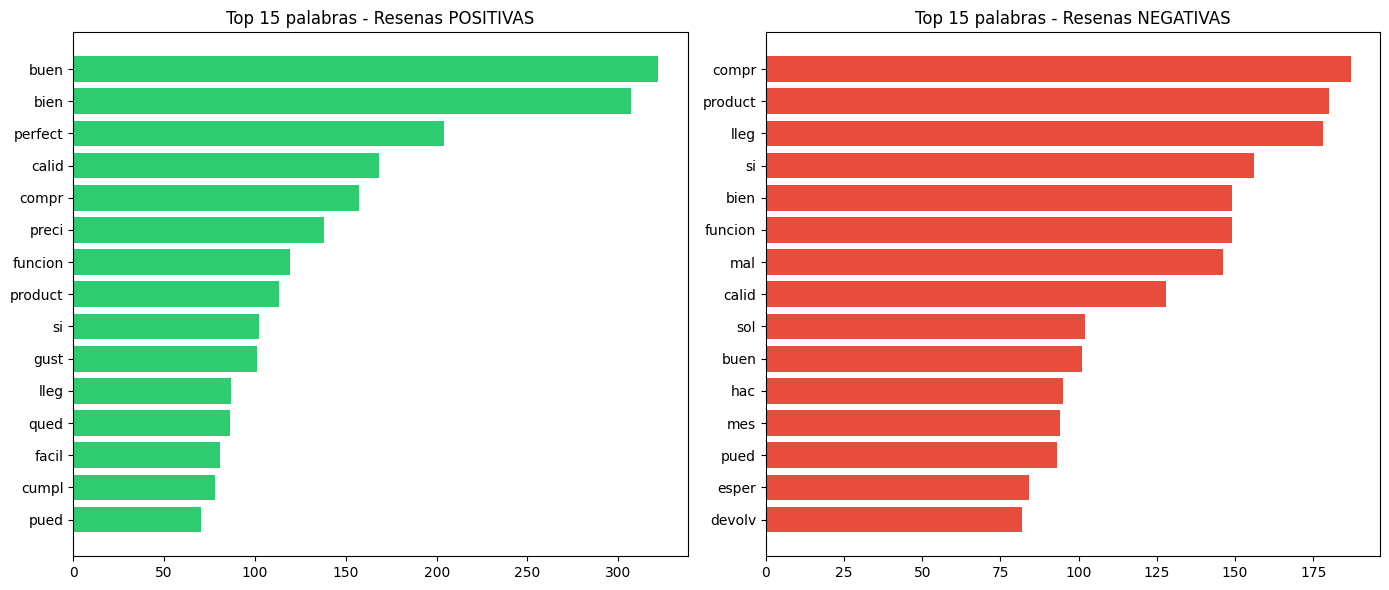

In [16]:
# Analizar las palabras mas frecuentes por sentimiento
palabras_pos = Counter()
palabras_neg = Counter()

muestra = df_sentimiento.sample(n=min(2000, len(df_sentimiento)), random_state=42)
for _, row in muestra.iterrows():
    tokens = preprocesar(row["text"])
    if row["sentimiento"] == "positivo":
        palabras_pos.update(tokens)
    else:
        palabras_neg.update(tokens)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Top palabras positivas
top_pos = palabras_pos.most_common(15)
palabras_p, freqs_p = zip(*top_pos)
axes[0].barh(range(len(palabras_p)), freqs_p, color='#2ecc71')
axes[0].set_yticks(range(len(palabras_p)))
axes[0].set_yticklabels(palabras_p)
axes[0].set_title('Top 15 palabras - Resenas POSITIVAS')
axes[0].invert_yaxis()

# Top palabras negativas
top_neg = palabras_neg.most_common(15)
palabras_n, freqs_n = zip(*top_neg)
axes[1].barh(range(len(palabras_n)), freqs_n, color='#e74c3c')
axes[1].set_yticks(range(len(palabras_n)))
axes[1].set_yticklabels(palabras_n)
axes[1].set_title('Top 15 palabras - Resenas NEGATIVAS')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

### Ejercicio practico 1

Modifica la funcion `preprocesar` para que **no** use stemming. Luego compara las palabras mas frecuentes con y sin stemming. Que diferencias notas?

In [17]:
# Tu codigo aqui
def preprocesar_sin_stem(texto):
    """Pipeline sin stemming."""
    pass  # Implementa aqui

# Prueba con una resena
# print(preprocesar_sin_stem(ejemplos[0]))

---
## 4. Representacion de texto: BoW y TF-IDF (~20 min)

Los modelos de machine learning necesitan **numeros**, no texto. Necesitamos convertir texto en vectores numericos.

### 4.1 Bag of Words (BoW)

La idea mas simple: contar cuantas veces aparece cada palabra en un documento.

```
"el gato come pescado" -> {el: 1, gato: 1, come: 1, pescado: 1}
"el perro come carne"  -> {el: 1, perro: 1, come: 1, carne: 1}
```

**Limitacion**: ignora el orden de las palabras y no captura significado.

In [18]:
from sklearn.feature_extraction.text import CountVectorizer

# Preparar textos limpios
textos_limpios = [limpiar_texto(t) for t in df_sentimiento["text"].tolist()]

# Crear el vectorizador BoW
bow_vectorizer = CountVectorizer(max_features=1000)
bow_matrix = bow_vectorizer.fit_transform(textos_limpios)

vocabulario = bow_vectorizer.get_feature_names_out()
print(f"Tamano del vocabulario: {len(vocabulario)}")
print(f"Primeras 20 palabras: {vocabulario[:20].tolist()}")
print(f"\nForma de la matriz: {bow_matrix.shape} (documentos x palabras)")

Tamano del vocabulario: 1000
Primeras 20 palabras: ['abajo', 'abierta', 'abierto', 'abre', 'abrir', 'acabado', 'acabados', 'acabo', 'accesorios', 'aceite', 'aceptable', 'acolchado', 'aconsejo', 'adapta', 'adaptador', 'ademas', 'además', 'agradable', 'agua', 'aguanta']

Forma de la matriz: (3997, 1000) (documentos x palabras)


In [19]:
# Visualizar la representacion de los primeros documentos
df_bow = pd.DataFrame(
    bow_matrix[:5].toarray(),
    columns=vocabulario,
    index=[f"doc_{i}" for i in range(5)]
)

# Mostrar solo columnas con valores > 0
cols_no_cero = df_bow.columns[(df_bow > 0).any()]
print(f"Palabras activas en los primeros 5 docs: {len(cols_no_cero)}")
df_bow[cols_no_cero]

Palabras activas en los primeros 5 docs: 51


,antes,cable,color,comentarios,con,conector,creo,cuando,de,después,...,retraso,rompe,se,si,tiempo,tienen,uno,unos,viene,yo
doc_0,0,1,0,0,0,1,0,0,0,0,...,0,0,1,0,1,0,0,0,0,0
doc_1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
doc_2,0,0,1,0,1,0,1,0,2,0,...,0,1,0,0,0,0,0,0,1,1
doc_3,1,0,0,1,0,0,0,1,2,0,...,1,0,1,1,0,0,1,0,0,0
doc_4,0,0,0,0,0,0,0,0,1,1,...,0,0,0,0,0,2,0,1,0,0


### 4.2 TF-IDF (Term Frequency - Inverse Document Frequency)

Mejora sobre BoW: no solo cuenta frecuencia, sino que **penaliza palabras que aparecen en muchos documentos** (son menos informativas).

$$\text{TF-IDF}(t, d) = \text{TF}(t, d) \times \text{IDF}(t)$$

- **TF(t, d)**: Frecuencia del termino `t` en el documento `d`
- **IDF(t)**: $\log\left(\frac{N}{\text{num docs que contienen } t}\right)$ — penaliza palabras muy comunes

In [20]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer(max_features=5000)
tfidf_matrix = tfidf_vectorizer.fit_transform(textos_limpios)

print(f"Forma de la matriz TF-IDF: {tfidf_matrix.shape}")

# Top palabras por TF-IDF para algunos documentos
tfidf_vocab = tfidf_vectorizer.get_feature_names_out()

print("\n=== Top 5 palabras por TF-IDF en las primeras 5 resenas ===")
for i in range(5):
    scores = tfidf_matrix[i].toarray().flatten()
    top_indices = scores.argsort()[-5:][::-1]
    top_palabras = [(tfidf_vocab[j], scores[j]) for j in top_indices]
    sent = df_sentimiento.iloc[i]["sentimiento"]
    top_str = ", ".join([f"{p}({s:.3f})" for p, s in top_palabras])
    print(f"Doc {i} [{sent:>8}]: {top_str}")

Forma de la matriz TF-IDF: (3997, 5000)

=== Top 5 palabras por TF-IDF en las primeras 5 resenas ===
Doc 0 [negativo]: acabó(0.390), duró(0.363), comodo(0.358), conector(0.354), largo(0.310)
Doc 1 [positivo]: necesidades(0.678), ideal(0.502), mis(0.497), para(0.204), engañado(0.000)
Doc 2 [negativo]: hilo(0.395), demasiada(0.368), mancha(0.363), rompe(0.310), facilidad(0.292)
Doc 3 [negativo]: serán(0.348), recibe(0.336), lunes(0.312), recibirla(0.312), retraso(0.283)
Doc 4 [negativo]: pasa(0.336), tienen(0.284), que(0.238), yosi(0.238), narices(0.227)


### Ejercicio practico 2

Crea un `TfidfVectorizer` que:
1. Ignore palabras que aparecen en mas del 80% de los documentos (`max_df=0.8`)
2. Ignore palabras que aparecen en menos de 5 documentos (`min_df=5`)
3. Considere unigramas y bigramas (`ngram_range=(1, 2)`)

Observa como cambia el vocabulario.

In [21]:
# Tu codigo aqui
# tfidf_v2 = TfidfVectorizer(max_df=???, min_df=???, ngram_range=???)
# ...

---
## 5. Clasificacion de sentimiento con Machine Learning (~25 min)

Ahora vamos a construir un clasificador de sentimiento **con datos reales de Amazon**.

### 5.1 Preparar los datos

In [22]:
from sklearn.model_selection import train_test_split

# Vectorizar con TF-IDF
vectorizer = TfidfVectorizer(max_features=5000, max_df=0.9, min_df=2)
X = vectorizer.fit_transform(textos_limpios)
y = np.array([1 if s == "positivo" else 0 for s in df_sentimiento["sentimiento"]])

# Dividir en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Entrenamiento: {X_train.shape[0]} resenas")
print(f"Prueba: {X_test.shape[0]} resenas")
print(f"Dimensiones del vector: {X_train.shape[1]} features")
print(f"\nBalance de clases (train):")
print(f"  Positivo: {(y_train == 1).sum()} ({(y_train == 1).mean():.1%})")
print(f"  Negativo: {(y_train == 0).sum()} ({(y_train == 0).mean():.1%})")

Entrenamiento: 3197 resenas
Prueba: 800 resenas
Dimensiones del vector: 4440 features

Balance de clases (train):
  Positivo: 1606 (50.2%)
  Negativo: 1591 (49.8%)


### 5.2 Entrenar y comparar modelos

In [23]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, accuracy_score

modelos = {
    "Naive Bayes": MultinomialNB(),
    "Regresion Logistica": LogisticRegression(max_iter=1000, random_state=42),
    "SVM Lineal": LinearSVC(max_iter=1000, random_state=42),
}

resultados = {}
for nombre, modelo in modelos.items():
    modelo.fit(X_train, y_train)
    y_pred = modelo.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    resultados[nombre] = acc
    print(f"\n{'='*50}")
    print(f"Modelo: {nombre}")
    print(f"Accuracy: {acc:.2%}")
    print(classification_report(y_test, y_pred, target_names=["negativo", "positivo"]))


Modelo: Naive Bayes
Accuracy: 83.50%
              precision    recall  f1-score   support

    negativo       0.84      0.83      0.83       398
    positivo       0.83      0.84      0.84       402

    accuracy                           0.83       800
   macro avg       0.84      0.83      0.83       800
weighted avg       0.84      0.83      0.83       800


Modelo: Regresion Logistica
Accuracy: 83.88%
              precision    recall  f1-score   support

    negativo       0.84      0.83      0.84       398
    positivo       0.83      0.85      0.84       402

    accuracy                           0.84       800
   macro avg       0.84      0.84      0.84       800
weighted avg       0.84      0.84      0.84       800


Modelo: SVM Lineal
Accuracy: 84.38%
              precision    recall  f1-score   support

    negativo       0.84      0.84      0.84       398
    positivo       0.84      0.85      0.84       402

    accuracy                           0.84       800
   macr

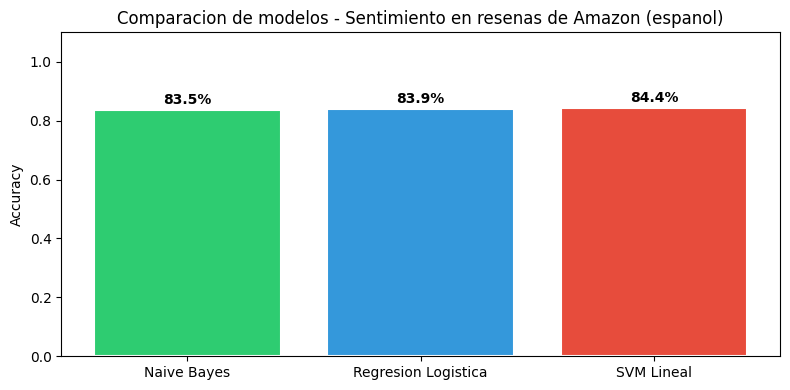

In [24]:
# Comparar modelos visualmente
plt.figure(figsize=(8, 4))
nombres = list(resultados.keys())
accuracies = list(resultados.values())
colores = ['#2ecc71', '#3498db', '#e74c3c']

bars = plt.bar(nombres, accuracies, color=colores, edgecolor='white', linewidth=1.5)
plt.ylabel('Accuracy')
plt.title('Comparacion de modelos - Sentimiento en resenas de Amazon (espanol)')
plt.ylim(0, 1.1)

for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'{acc:.1%}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

### 5.3 Probar con nuestras propias resenas

In [25]:
mejor_modelo = modelos["Regresion Logistica"]

nuevas_resenas = [
    "Excelente producto, me encanto la calidad!",
    "No sirve para nada, muy mala calidad",
    "Llego rapido pero el producto no es como en las fotos",
    "Muy bueno por el precio, lo recomiendo",
    "Pesimo, pedi la devolucion inmediatamente",
    "Funciona bien, cumple con lo esperado",
]

X_nuevas = vectorizer.transform([limpiar_texto(r) for r in nuevas_resenas])
predicciones = mejor_modelo.predict(X_nuevas)

print("=== Predicciones para nuevas resenas ===")
for resena, pred in zip(nuevas_resenas, predicciones):
    sentimiento = "POSITIVO" if pred == 1 else "NEGATIVO"
    print(f"[{sentimiento:>8}] {resena}")

=== Predicciones para nuevas resenas ===
[POSITIVO] Excelente producto, me encanto la calidad!
[NEGATIVO] No sirve para nada, muy mala calidad
[NEGATIVO] Llego rapido pero el producto no es como en las fotos
[POSITIVO] Muy bueno por el precio, lo recomiendo
[NEGATIVO] Pesimo, pedi la devolucion inmediatamente
[POSITIVO] Funciona bien, cumple con lo esperado


### 5.4 Que palabras son mas importantes para el modelo?

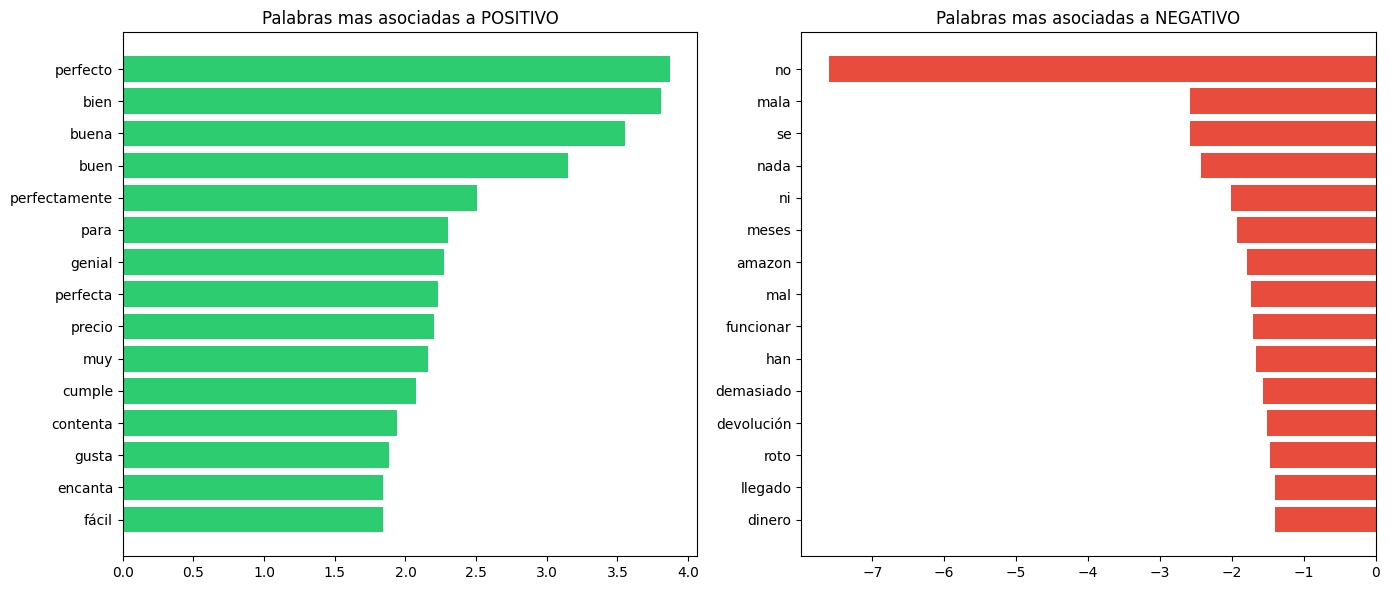

In [26]:
# Coeficientes de la Regresion Logistica
feature_names = vectorizer.get_feature_names_out()
coeficientes = mejor_modelo.coef_[0]

top_k = 15
top_pos_idx = coeficientes.argsort()[-top_k:][::-1]
top_neg_idx = coeficientes.argsort()[:top_k]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Palabras mas positivas
palabras_pos_model = [feature_names[i] for i in top_pos_idx]
coefs_pos = [coeficientes[i] for i in top_pos_idx]
axes[0].barh(range(top_k), coefs_pos, color='#2ecc71')
axes[0].set_yticks(range(top_k))
axes[0].set_yticklabels(palabras_pos_model)
axes[0].set_title('Palabras mas asociadas a POSITIVO')
axes[0].invert_yaxis()

# Palabras mas negativas
palabras_neg_model = [feature_names[i] for i in top_neg_idx]
coefs_neg = [coeficientes[i] for i in top_neg_idx]
axes[1].barh(range(top_k), coefs_neg, color='#e74c3c')
axes[1].set_yticks(range(top_k))
axes[1].set_yticklabels(palabras_neg_model)
axes[1].set_title('Palabras mas asociadas a NEGATIVO')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

### Ejercicio practico 3

1. Escribe 3-5 resenas tuyas (como si compraras en Amazon) y prueba el clasificador
2. Intenta encontrar un caso donde falle (sarcasmo, negacion, etc.)
3. Por que crees que falla en esos casos?

In [27]:
# Tu codigo aqui
mis_resenas = [
    # Escribe tus resenas aqui
]

# X_mis = vectorizer.transform([limpiar_texto(r) for r in mis_resenas])
# predicciones_mis = mejor_modelo.predict(X_mis)
# for resena, pred in zip(mis_resenas, predicciones_mis):
#     sentimiento = "POSITIVO" if pred == 1 else "NEGATIVO"
#     print(f"[{sentimiento:>8}] {resena}")

### Ejercicio practico 4 (bonus)

En vez de sentimiento binario, intenta clasificar las **5 estrellas** directamente (multiclase). Como cambia el rendimiento? Cuales son las clases mas dificiles de distinguir?

In [28]:
# Tu codigo aqui
# Pista: usa df en vez de df_sentimiento, y label como target
# ...

---
## 6. Introduccion a Word Embeddings (~15 min)

### Limitaciones de BoW y TF-IDF

- No capturan **relaciones semanticas** entre palabras
- "excelente" y "genial" son igual de diferentes que "excelente" y "horrible"
- Vectores **dispersos** (sparse) y de alta dimension

### Que son los Word Embeddings?

Son representaciones **densas** de palabras en un espacio vectorial de baja dimension (100-300 dimensiones) donde **palabras con significado similar estan cerca** entre si.

```
rey - hombre + mujer = reina
paris - francia + espana = madrid
```

### Modelos populares:
- **Word2Vec** (Google, 2013)
- **GloVe** (Stanford, 2014)
- **FastText** (Facebook, 2016)

### 6.1 Entrenando Word2Vec con resenas de Amazon

In [29]:
from gensim.models import Word2Vec

# Tokenizar todas las resenas
corpus_tokenizado = [
    word_tokenize(limpiar_texto(doc), language='spanish')
    for doc in df_sentimiento["text"].tolist()
]

print(f"Documentos en el corpus: {len(corpus_tokenizado)}")
print(f"Ejemplo: {corpus_tokenizado[0][:10]}...")

Documentos en el corpus: 3997
Ejemplo: ['el', 'cable', 'es', 'muy', 'largo', 'y', 'es', 'comodo', 'pero', 'me']...


In [30]:
# Entrenar Word2Vec
modelo_w2v = Word2Vec(
    sentences=corpus_tokenizado,
    vector_size=100,
    window=5,
    min_count=3,
    workers=4,
    epochs=30,
    seed=42,
)

print(f"Vocabulario del modelo: {len(modelo_w2v.wv)} palabras")
print(f"Dimensiones del vector: {modelo_w2v.wv.vector_size}")

Vocabulario del modelo: 3128 palabras
Dimensiones del vector: 100


In [31]:
# Palabras similares (semantica aprendida de las resenas!)
print("=== Palabras mas similares (aprendido de resenas de Amazon) ===")
for palabra in ["excelente", "malo", "producto", "envio", "precio"]:
    if palabra in modelo_w2v.wv:
        similares = modelo_w2v.wv.most_similar(palabra, topn=5)
        sim_str = ", ".join([f"{p}({s:.2f})" for p, s in similares])
        print(f"'{palabra}' -> {sim_str}")
    else:
        print(f"'{palabra}' no esta en el vocabulario")
    print()

=== Palabras mas similares (aprendido de resenas de Amazon) ===
'excelente' -> relación(0.85), relacion(0.85), excepcional(0.83), razonable(0.79), correctos(0.79)

'malo' -> endeble(0.79), fino(0.71), flojo(0.68), pesa(0.67), bueno(0.65)

'producto' -> artículo(0.75), articulo(0.75), libro(0.72), vendedor(0.72), modelo(0.67)

'envio' -> empaquetado(0.81), embalaje(0.79), llego(0.78), articulo(0.77), envío(0.77)

'precio' -> material(0.63), mejor(0.59), mucha(0.57), poca(0.57), producto(0.56)



### 6.2 Visualizacion de embeddings con PCA

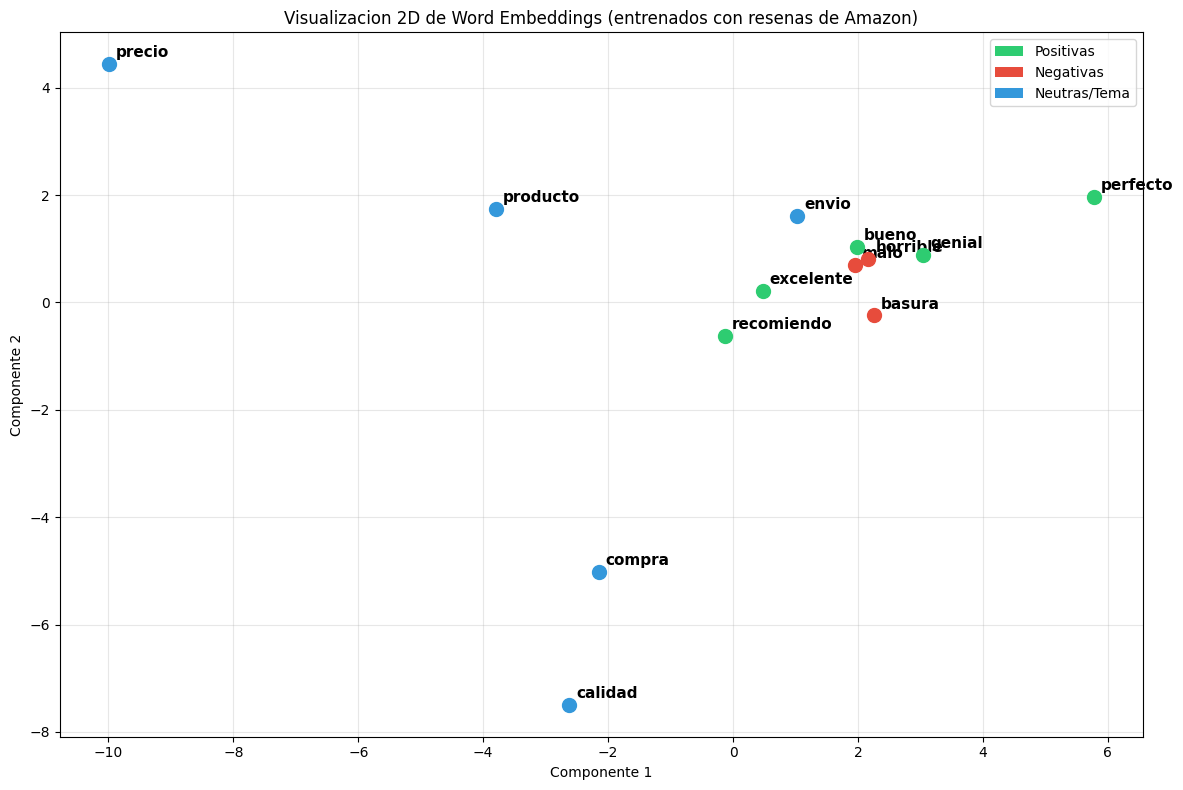

In [32]:
from sklearn.decomposition import PCA
from matplotlib.patches import Patch

# Palabras interesantes para visualizar
palabras_interes = [
    "excelente", "bueno", "genial", "perfecto", "recomiendo",
    "malo", "horrible", "pesimo", "terrible", "basura",
    "producto", "calidad", "envio", "precio", "compra",
]

# Filtrar las que existan en el vocabulario
palabras_validas = [p for p in palabras_interes if p in modelo_w2v.wv]
vectores = np.array([modelo_w2v.wv[p] for p in palabras_validas])

# Reducir a 2D
pca = PCA(n_components=2)
vectores_2d = pca.fit_transform(vectores)

plt.figure(figsize=(12, 8))

positivas = {"excelente", "bueno", "genial", "perfecto", "recomiendo"}
negativas = {"malo", "horrible", "pesimo", "terrible", "basura"}

for i, palabra in enumerate(palabras_validas):
    x, y_coord = vectores_2d[i]
    if palabra in positivas:
        color = '#2ecc71'
    elif palabra in negativas:
        color = '#e74c3c'
    else:
        color = '#3498db'
    plt.scatter(x, y_coord, c=color, s=100, zorder=5)
    plt.annotate(palabra, (x, y_coord), fontsize=11, fontweight='bold',
                 xytext=(5, 5), textcoords='offset points')

plt.title('Visualizacion 2D de Word Embeddings (entrenados con resenas de Amazon)')
plt.xlabel('Componente 1')
plt.ylabel('Componente 2')
plt.grid(True, alpha=0.3)

leyenda = [
    Patch(facecolor='#2ecc71', label='Positivas'),
    Patch(facecolor='#e74c3c', label='Negativas'),
    Patch(facecolor='#3498db', label='Neutras/Tema'),
]
plt.legend(handles=leyenda, loc='best')
plt.tight_layout()
plt.show()

### 6.3 De palabras a documentos

Para representar un documento completo con embeddings, una tecnica simple es **promediar los vectores** de todas sus palabras.

In [33]:
def documento_a_vector(tokens, modelo):
    """Convierte un documento a un vector promediando word embeddings."""
    vectores = [modelo.wv[t] for t in tokens if t in modelo.wv]
    if len(vectores) == 0:
        return np.zeros(modelo.wv.vector_size)
    return np.mean(vectores, axis=0)

# Ejemplo
tokens_ej = word_tokenize(
    limpiar_texto(df_sentimiento.iloc[0]["text"]), language='spanish'
)
vec_doc = documento_a_vector(tokens_ej, modelo_w2v)

print(f"Resena: {str(df_sentimiento.iloc[0]['text'])[:80]}...")
print(f"Vector (primeros 10): {vec_doc[:10].round(4)}")
print(f"Dimension: {len(vec_doc)}")

Resena: El cable es muy largo y es comodo pero me duró poco tiempo porque el conector mi...
Vector (primeros 10): [ 0.3365  0.381  -0.0952  0.0413 -0.1145  0.1867 -0.3116  0.2968 -0.0943
 -0.0349]
Dimension: 100


### Ejercicio practico 5

Usa los vectores de `documento_a_vector` como features para entrenar un clasificador. Compara con TF-IDF de la seccion 5. Cual funciona mejor? Por que?

In [34]:
# Tu codigo aqui
# 1. Convertir todas las resenas a vectores
# X_w2v = np.array([documento_a_vector(tokens, modelo_w2v) for tokens in corpus_tokenizado])
# 2. Dividir en train/test
# 3. Entrenar un modelo (ej: LogisticRegression)
# 4. Evaluar y comparar

---
## 7. Cierre y recursos adicionales (~5 min)

### Resumen de lo aprendido

| Concepto | Descripcion |
|----------|-------------|
| **Dataset real** | 200K resenas de Amazon en espanol |
| **Preprocesamiento** | Limpieza, tokenizacion, stopwords, stemming |
| **BoW** | Representacion simple contando palabras |
| **TF-IDF** | BoW mejorado que penaliza palabras muy comunes |
| **Clasificacion** | Naive Bayes, Regresion Logistica, SVM para sentimiento |
| **Word Embeddings** | Representaciones densas que capturan semantica |

### Lo que NO cubrimos (temas para futuras sesiones)

- **Redes neuronales recurrentes (RNN, LSTM)** para secuencias
- **Transformers y atencion** (BERT, GPT, etc.)
- **NER** (Named Entity Recognition)
- **Generacion de texto** con modelos de lenguaje
- **Transfer learning** con modelos pre-entrenados (BETO, RoBERTa)

### Recursos para seguir aprendiendo

- **Libros:**
  - *Speech and Language Processing* - Jurafsky & Martin (gratis online)
  - *Natural Language Processing with Python* - Bird, Klein & Loper

- **Cursos:**
  - Stanford CS224N: NLP with Deep Learning
  - Hugging Face NLP Course (gratuito)

- **Librerias:**
  - `spaCy` - NLP industrial
  - `Hugging Face Transformers` - Modelos pre-entrenados
  - `NLTK` - Herramientas educativas

### Desafio para casa

Usando el dataset completo (200K resenas):

1. Entrena con **todas** las resenas (no solo la muestra de 5000)
2. Intenta la clasificacion **multiclase** (5 estrellas) y analiza la matriz de confusion
3. Experimenta con bigramas y trigramas en TF-IDF
4. Compara Word2Vec entrenado con 5K vs 200K resenas: mejoran los embeddings?

Comparte tus resultados en la proxima sesion!